# LFP Battery Pack Should-Cost Reconstruction

This notebook reconstructs the **2026 low-cost LFP, 75-kWh BEV pack scenario** published by Argonne National Laboratory in *Cost of Automotive Batteries for Electric Vehicles — Update 2024* (ANL/CSE-24/1).

The scenario assumes a 125-Ah LFP cell, a 95% graphite / 5% silicon anode, a 50-GWh/year plant, and 92% cell yield (Table 10).

### What is directly sourced vs. calculated

- Component prices come from Argonne Tables 11 and 12.
- Material cost contributions come from Argonne Table 28.
- Physical quantities are **implied quantities**, calculated as Argonne cost contribution ÷ Argonne unit price.
- The full pack-cost stack comes from Argonne Table 27.
- This is a reconstruction and sensitivity tool, not a supplier quotation or a full reimplementation of BatPaC.

Primary source: https://publications.anl.gov/anlpubs/2024/01/187177.pdf

In [1]:
# Material inputs: Argonne Tables 11, 12, and 28
# Mixed units are intentional: active materials are $/kg, collectors and
# separator are $/m², and electrolyte is $/L.

material_inputs = {
    "LFP cathode active": {
        "price": 11.50, "price_unit": "$/kg",
        "cost_contribution": 25.76, "quantity_unit": "kg/kWh"
    },
    "95% graphite / 5% silicon anode": {
        "price": 10.10, "price_unit": "$/kg",
        "cost_contribution": 8.38, "quantity_unit": "kg/kWh"
    },
    "Positive current collector (Al)": {
        "price": 0.20, "price_unit": "$/m²",
        "cost_contribution": 1.18, "quantity_unit": "m²/kWh"
    },
    "Negative current collector (Cu)": {
        "price": 1.20, "price_unit": "$/m²",
        "cost_contribution": 7.38, "quantity_unit": "m²/kWh"
    },
    "Separator": {
        "price": 0.50, "price_unit": "$/m²",
        "cost_contribution": 5.12, "quantity_unit": "m²/kWh"
    },
    "Electrolyte": {
        "price": 10.00, "price_unit": "$/L",
        "cost_contribution": 4.55, "quantity_unit": "L/kWh"
    },
}

# Table 28 reports carbon and binder together. Because it combines multiple
# ingredients with different prices, preserve it as an aggregate $/kWh item.
carbon_and_binder_cost = 3.21

for item in material_inputs.values():
    item["implied_quantity"] = item["cost_contribution"] / item["price"]

print(f"{'Material / component':<37} {'Quantity':>11} {'Unit price':>13} {'Cost':>10}")
print("-" * 75)
for name, item in material_inputs.items():
    quantity = f"{item['implied_quantity']:.3f} {item['quantity_unit']}"
    unit_price = f"{item['price']:.2f} {item['price_unit']}"
    cost = f"${item['cost_contribution']:.2f}/kWh"
    print(f"{name:<37} {quantity:>17} {unit_price:>15} {cost:>12}")
print(f"{'Carbon and binder (aggregate)':<37} {'—':>17} {'—':>15} {'$3.21/kWh':>12}")

total_materials = (
    sum(item["cost_contribution"] for item in material_inputs.values())
    + carbon_and_binder_cost
)
print("-" * 85)
print(f"{'RECONSTRUCTED MATERIAL TOTAL':<71} ${total_materials:.2f}/kWh")
print("Argonne Table 28 material total:                              $55.50/kWh")
print("Difference is caused by rounding in the published line items.")

Material / component                     Quantity    Unit price       Cost
---------------------------------------------------------------------------
LFP cathode active                         2.240 kg/kWh      11.50 $/kg   $25.76/kWh
95% graphite / 5% silicon anode            0.830 kg/kWh      10.10 $/kg    $8.38/kWh
Positive current collector (Al)            5.900 m²/kWh       0.20 $/m²    $1.18/kWh
Negative current collector (Cu)            6.150 m²/kWh       1.20 $/m²    $7.38/kWh
Separator                                 10.240 m²/kWh       0.50 $/m²    $5.12/kWh
Electrolyte                                 0.455 L/kWh       10.00 $/L    $4.55/kWh
Carbon and binder (aggregate)                         —               —    $3.21/kWh
-------------------------------------------------------------------------------------
RECONSTRUCTED MATERIAL TOTAL                                            $55.58/kWh
Argonne Table 28 material total:                              $55.50/kWh
Difference i

## How to explain the material intensities

The notebook does **not** claim that the implied quantities are universal LFP recipes. For this defined Argonne scenario:

> implied quantity per kWh = published cost contribution per kWh ÷ published component price

For example, LFP cathode active material is $25.76/kWh ÷ $11.50/kg = **2.24 kg/kWh**. This makes the reconstruction auditable while preserving the source's mixed physical units.

In [2]:
# Full pack-cost stack: Argonne Table 27, 2026 low-cost LFP 75-kWh BEV

pack_cost_items = {
    "Materials (reconstructed)": total_materials,
    "Purchased items": 11.60,
    "Battery management system": 5.20,
    "Energy": 1.70,
    "Depreciation": 7.00,
    "Labor-related": 3.70,
    "Other variable overhead": 1.90,
    "Other GSA": 1.20,
    "R&D": 2.40,
    "Financing": 0.80,
    "Profit": 5.60,
    "Warranty": 5.40,
}

reconstructed_pack_cost = sum(pack_cost_items.values())
argonne_reference_total = 102.20
rounding_gap = argonne_reference_total - reconstructed_pack_cost

print(f"{'Pack cost item':<34} {'$/kWh':>10}")
print("-" * 46)
for item, cost in pack_cost_items.items():
    print(f"{item:<34} {cost:>10.2f}")
print("-" * 46)
print(f"{'RECONSTRUCTED PACK COST':<34} {reconstructed_pack_cost:>10.2f}")
print(f"{'ARGONNE TABLE 27 TOTAL':<34} {argonne_reference_total:>10.2f}")
print(f"{'ROUNDING GAP':<34} {rounding_gap:>10.2f}")

Pack cost item                          $/kWh
----------------------------------------------
Materials (reconstructed)               55.58
Purchased items                         11.60
Battery management system                5.20
Energy                                   1.70
Depreciation                             7.00
Labor-related                            3.70
Other variable overhead                  1.90
Other GSA                                1.20
R&D                                      2.40
Financing                                0.80
Profit                                   5.60
Warranty                                 5.40
----------------------------------------------
RECONSTRUCTED PACK COST                102.08
ARGONNE TABLE 27 TOTAL                 102.20
ROUNDING GAP                             0.12


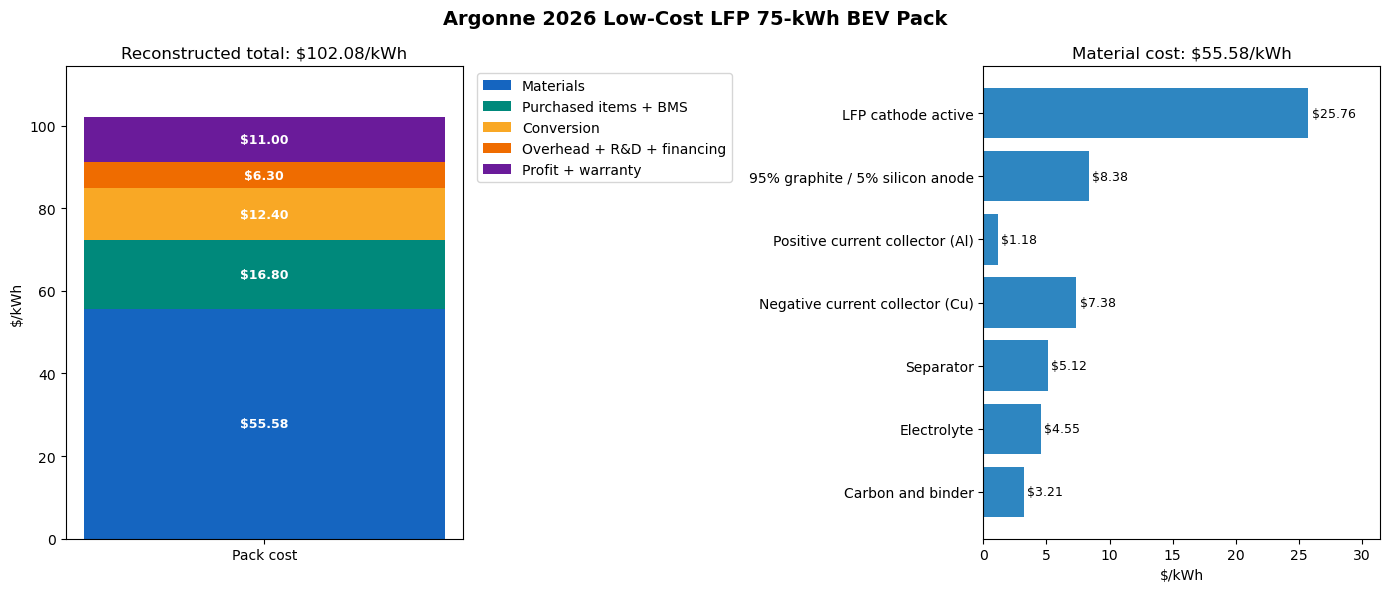

Chart saved as cost_breakdown.png


In [3]:
# Cost-breakdown charts
import matplotlib.pyplot as plt

material_names = list(material_inputs.keys()) + ["Carbon and binder"]
material_values = [
    item["cost_contribution"] for item in material_inputs.values()
] + [carbon_and_binder_cost]

grouped_costs = {
    "Materials": total_materials,
    "Purchased items + BMS": 11.60 + 5.20,
    "Conversion": 1.70 + 7.00 + 3.70,
    "Overhead + R&D + financing": 1.90 + 1.20 + 2.40 + 0.80,
    "Profit + warranty": 5.60 + 5.40,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Argonne 2026 Low-Cost LFP 75-kWh BEV Pack", fontsize=14, fontweight="bold")

colors = ["#1565C0", "#00897B", "#F9A825", "#EF6C00", "#6A1B9A"]
bottom = 0
for (label, value), color in zip(grouped_costs.items(), colors):
    ax1.bar(["Pack cost"], value, bottom=bottom, color=color, label=label, width=0.45)
    ax1.text(0, bottom + value / 2, f"${value:.2f}", ha="center", va="center",
             color="white", fontweight="bold", fontsize=9)
    bottom += value
ax1.set_ylabel("$/kWh")
ax1.set_title(f"Reconstructed total: ${reconstructed_pack_cost:.2f}/kWh")
ax1.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
ax1.set_ylim(0, reconstructed_pack_cost * 1.12)

bars = ax2.barh(material_names, material_values, color="#2E86C1")
ax2.set_xlabel("$/kWh")
ax2.set_title(f"Material cost: ${total_materials:.2f}/kWh")
ax2.invert_yaxis()
for bar, value in zip(bars, material_values):
    ax2.text(value + 0.25, bar.get_y() + bar.get_height() / 2,
             f"${value:.2f}", va="center", fontsize=9)
ax2.set_xlim(0, max(material_values) * 1.22)

plt.tight_layout()
plt.savefig("cost_breakdown.png", dpi=160, bbox_inches="tight")
plt.show()
print("Chart saved as cost_breakdown.png")

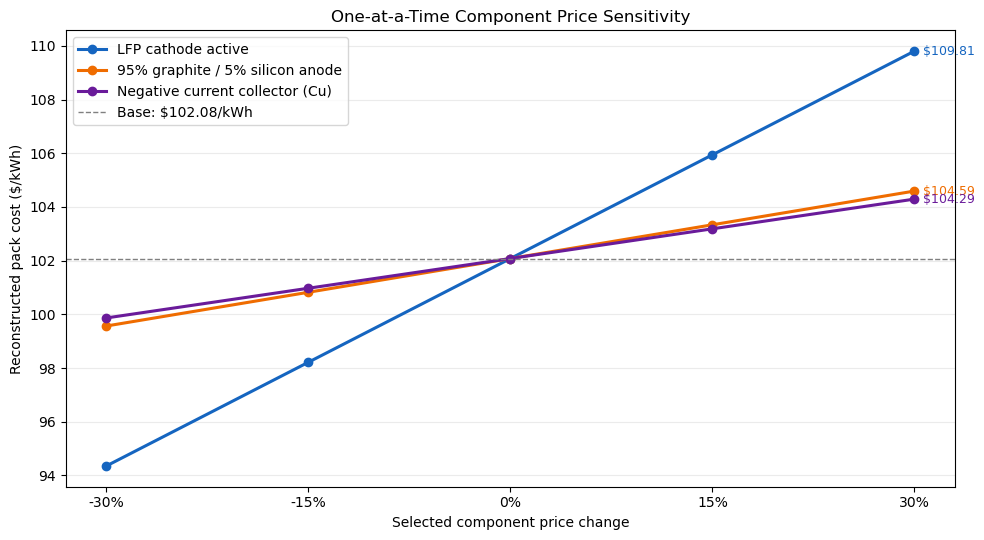

Chart saved as sensitivity.png

Impact of a ±30% component-price move:
  LFP cathode active                      ±$7.73/kWh
  95% graphite / 5% silicon anode         ±$2.51/kWh
  Negative current collector (Cu)         ±$2.21/kWh


In [4]:
# One-at-a-time price sensitivity
# Quantity stays fixed and all non-selected costs stay fixed.
import numpy as np

sensitivity_components = [
    "LFP cathode active",
    "95% graphite / 5% silicon anode",
    "Negative current collector (Cu)",
]
swings = np.array([-0.30, -0.15, 0.0, 0.15, 0.30])

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ["#1565C0", "#EF6C00", "#6A1B9A"]

for component, color in zip(sensitivity_components, colors):
    base_contribution = material_inputs[component]["cost_contribution"]
    totals = reconstructed_pack_cost + base_contribution * swings
    ax.plot(swings * 100, totals, marker="o", linewidth=2.2,
            label=component, color=color)
    ax.annotate(f"${totals[-1]:.2f}", (30, totals[-1]),
                xytext=(6, 0), textcoords="offset points",
                va="center", color=color, fontsize=9)

ax.axhline(reconstructed_pack_cost, color="gray", linestyle="--", linewidth=1,
           label=f"Base: ${reconstructed_pack_cost:.2f}/kWh")
ax.set_xlabel("Selected component price change")
ax.set_ylabel("Reconstructed pack cost ($/kWh)")
ax.set_title("One-at-a-Time Component Price Sensitivity")
ax.set_xticks(swings * 100)
ax.set_xticklabels([f"{int(x)}%" for x in swings * 100])
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()
print("Chart saved as sensitivity.png")

print("\nImpact of a ±30% component-price move:")
for component in sensitivity_components:
    impact = material_inputs[component]["cost_contribution"] * 0.30
    print(f"  {component:<39} ±${impact:.2f}/kWh")

In [5]:
# Summary and external benchmark

bnef_lfp_pack_2025 = 81.0
bnef_stationary_pack_2025 = 70.0

print("=" * 70)
print("LFP BATTERY PACK SHOULD-COST RECONSTRUCTION")
print("=" * 70)
print(f"Reconstructed Argonne scenario: ${reconstructed_pack_cost:.2f}/kWh")
print(f"Published Argonne total:        ${argonne_reference_total:.2f}/kWh")
print(f"Published BNEF 2025 LFP avg.:   ${bnef_lfp_pack_2025:.2f}/kWh")
print(f"Published BNEF 2025 storage:    ${bnef_stationary_pack_2025:.2f}/kWh")
print()
print("Interpretation:")
print("- The reconstruction matches Argonne to within published-table rounding.")
print("- Argonne is a modeled U.S. automotive pack scenario; BNEF reports")
print("  observed global market averages. They are useful context, not a")
print("  like-for-like validation target.")
print("- The model is best used to identify cost drivers and run controlled")
print("  scenarios, not to predict an executable supplier quote.")
print()
print("Sources:")
print("- Argonne ANL/CSE-24/1, Tables 10-12 and 27-28:")
print("  https://publications.anl.gov/anlpubs/2024/01/187177.pdf")
print("- BloombergNEF 2025 Battery Price Survey release:")
print("  https://about.bnef.com/insights/clean-transport/"
      "lithium-ion-battery-pack-prices-fall-to-108-per-kilowatt-hour-"
      "despite-rising-metal-prices-bloombergnef/")

LFP BATTERY PACK SHOULD-COST RECONSTRUCTION
Reconstructed Argonne scenario: $102.08/kWh
Published Argonne total:        $102.20/kWh
Published BNEF 2025 LFP avg.:   $81.00/kWh
Published BNEF 2025 storage:    $70.00/kWh

Interpretation:
- The reconstruction matches Argonne to within published-table rounding.
- Argonne is a modeled U.S. automotive pack scenario; BNEF reports
  observed global market averages. They are useful context, not a
  like-for-like validation target.
- The model is best used to identify cost drivers and run controlled
  scenarios, not to predict an executable supplier quote.

Sources:
- Argonne ANL/CSE-24/1, Tables 10-12 and 27-28:
  https://publications.anl.gov/anlpubs/2024/01/187177.pdf
- BloombergNEF 2025 Battery Price Survey release:
  https://about.bnef.com/insights/clean-transport/lithium-ion-battery-pack-prices-fall-to-108-per-kilowatt-hour-despite-rising-metal-prices-bloombergnef/
